In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
class RateCalculations:
    def __init__(self, mass_DM, omega_val, q_list, s_factor, cross_section):
        c = 2.998e5 # in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        
        # Swapped: single omega, array of q
        self.omega_val = omega_val
        self.q_list = q_list 
        self.s_factor = s_factor
        
        self.cross_section = cross_section # cm^2
        self.v_max = self.v_esc + self.v_earth 
        self.num_density = 2.15e25 # per kg
        
        self.keV2InvS = 2.418e17 # keV to 1/s
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6

    def get_v_min(self, mass_DM, q_arr):
        return self.omega_val / q_arr + q_arr / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) 
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self, v_min): 
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral

    def get_inverse_mean_func(self, mass_DM, q_arr): 
        v_min = self.get_v_min(mass_DM, q_arr)
        return np.where(v_min > (self.v_esc + self.v_earth), 0., 
                        np.where(v_min < (self.v_esc - self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    def get_diff_rate_dRdomega(self):
        reducedMass = self.mass_DM * self.mass_proton / (self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4 * np.pi * self.density_target * self.mass_DM * reducedMass**2)
        # Integrand includes q_list to complete the integration over dq
        integrand = self.q_list * self.get_inverse_mean_func(self.mass_DM, self.q_list) * self.s_factor
        return constFactor * sp.integrate.simpson(integrand, self.q_list) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg

In [3]:
nSiteData = np.load("testMultiprocess.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]

In [4]:
def get_impulse_approx(q_list, omega, omega_avg=30e-6):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q_list**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega-(q_list**2/(2*mass)))**2 / (2*deltasq)) 

def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [5]:
max(omega_list_nSite)*1e6

250.0

In [6]:
cross_section = 1e-40 # cm^2
omega_avg = 13.13e-6

dm_length = 200
dmmasslist_4plot = np.array([100, 1e3, 40e3, 100e3, 1e6]) # 10^2 ~ 10^6 keV
omega_threshold = 1e-6 # keV

dRdomega_result_4plot = []
dRdomega_result_incoh_4plot = []

# Constants for Impulse Approximation (IA)
mass_si = 26161e3 # Silicon mass in keV
latticeConst = 2 * np.pi / 2.28 
omega_avg = 13.13e-6 # Average phonon energy from your data
cross_section = 1e-40 
omega_threshold = 1e-6

def calculate_rates_for_masses(dmmasslist, q_list_nSite, omega_list_nSite, s_factor_nSite, s_factor_nSite_incoh):
    """
    Calculates dR/domega for various DM masses, extending the q-range via 
    Impulse Approximation where necessary.
    """
    # Results containers: Shape will be (len(dmmasslist), len(omega_list_nSite))
    dRdomega_result_4plot = []
    dRdomega_result_incoh_4plot = []

    # Constants for RateCalculations (Assumed cross section for example)
    sigma_n = 1e-40 # cm^2

    for m_dm in dmmasslist:
        mass_rates_tot = []
        mass_rates_incoh = []
        
        # Get global q limits for this mass to check if extension is needed
        # We use the threshold of the current omega being processed in the loop
        for i, omega in enumerate(omega_list_nSite):
            q_min_lim, q_max_lim = get_q_lim(m_dm, omega_threshold=omega)
            
            current_q_max = np.max(q_list_nSite)
            
            # Check if we need to append more q values
            if q_max_lim > current_q_max:
                # Generate 2000 new points from current max to the required q_max
                q_extra = np.linspace(current_q_max, q_max_lim, 2000)
                q_combined = np.concatenate([q_list_nSite, q_extra])
                
                # Calculate Impulse Approx for the new q range
                s_extra = get_impulse_approx(q_extra, omega)
                
                # Combine original data for this specific omega with the new points
                # s_factor_nSite is (q, omega), so we take the column for current omega
                s_tot_combined = np.concatenate([s_factor_nSite[:, i], s_extra])
                s_incoh_combined = np.concatenate([s_factor_nSite_incoh[:, i], s_extra])
            else:
                q_combined = q_list_nSite
                s_tot_combined = s_factor_nSite[:, i]
                s_incoh_combined = s_factor_nSite_incoh[:, i]

            # Initialize the RateCalculations for this specific omega and DM mass
            # Total Rate
            calc_tot = RateCalculations(m_dm, omega, q_combined, s_tot_combined, sigma_n)
            mass_rates_tot.append(calc_tot.get_diff_rate_dRdomega())
            
            # Incoherent Rate
            calc_incoh = RateCalculations(m_dm, omega, q_combined, s_incoh_combined, sigma_n)
            mass_rates_incoh.append(calc_incoh.get_diff_rate_dRdomega())
            
        dRdomega_result_4plot.append(mass_rates_tot)
        dRdomega_result_incoh_4plot.append(mass_rates_incoh)

    return np.array(dRdomega_result_4plot), np.array(dRdomega_result_incoh_4plot)



In [7]:
# --- Execution ---
dmmasslist_4plot = np.array([1e2, 1e3, 40e3, 100e3, 1e6])

dRdomega_result_4plot, dRdomega_result_incoh_4plot = calculate_rates_for_masses(
    dmmasslist_4plot, q_list_nSite, omega_list_nSite, s_factor_nSite, s_factor_nSite_incoh
)
            

In [8]:
def calculate_rates_impulse_only(dmmasslist, omega_list):
    """
    Calculates dR/domega using ONLY the impulse approximation.
    Generates 3000 q values between q_min and q_max for each omega.
    """
    # Results containers
    dRdomega_result_4plot = []
    dRdomega_result_incoh_4plot = []

    # Constants
    sigma_n = 1e-40 # cm^2 (example cross section, adjust as needed)
    v_max = 0.00247 # in c (matching your get_q_lim function)

    for m_dm in dmmasslist:
        mass_rates_tot = []
        mass_rates_incoh = []
        
        for omega in omega_list:
            # Kinematic limit check: 
            # 2 * omega must be <= mass_DM * v_max^2 to be physically possible.
            # This prevents math errors (negative square roots) in get_q_lim.
            if 2 * omega > m_dm * (v_max**2):
                mass_rates_tot.append(0.0)
                mass_rates_incoh.append(0.0)
                continue
            
            # Get q limits for this specific mass and omega
            q_min, q_max = get_q_lim(m_dm, omega_threshold=omega)
            
            # Generate exactly 3000 q values between the allowed limits
            q_list_impulse = np.linspace(q_min, q_max, 3000)
            
            # Calculate structure factor using purely the impulse approximation
            s_factor_impulse = get_impulse_approx(q_list_impulse, omega)
            
            # Initialize RateCalculations and compute the rate
            calc = RateCalculations(m_dm, omega, q_list_impulse, s_factor_impulse, sigma_n)
            rate = calc.get_diff_rate_dRdomega()
            
            # Since total and incoh are identical under pure impulse approx, 
            # we append the same calculated rate to both lists
            mass_rates_tot.append(rate)
            mass_rates_incoh.append(rate)
            
        dRdomega_result_4plot.append(mass_rates_tot)
        dRdomega_result_incoh_4plot.append(mass_rates_incoh)

    return np.array(dRdomega_result_4plot), np.array(dRdomega_result_incoh_4plot)



In [9]:
# --- Execution ---
# Generate the new arrays for plotting
dRdomega_impulse_tot, dRdomega_impulse_incoh = calculate_rates_impulse_only(
    dmmasslist_4plot, omega_list_nSite
)

C:\Users\xylin\AppData\Local\Temp\ipykernel_22920\1738809985.py:5: RuntimeWarning: divide by zero encountered in divide
  return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega-(q_list**2/(2*mass)))**2 / (2*deltasq))
C:\Users\xylin\AppData\Local\Temp\ipykernel_22920\1738809985.py:5: RuntimeWarning: invalid value encountered in divide
  return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega-(q_list**2/(2*mass)))**2 / (2*deltasq))
C:\Users\xylin\AppData\Local\Temp\ipykernel_22920\1903238586.py:28: RuntimeWarning: invalid value encountered in divide
  return self.omega_val / q_arr + q_arr / (2 * mass_DM)


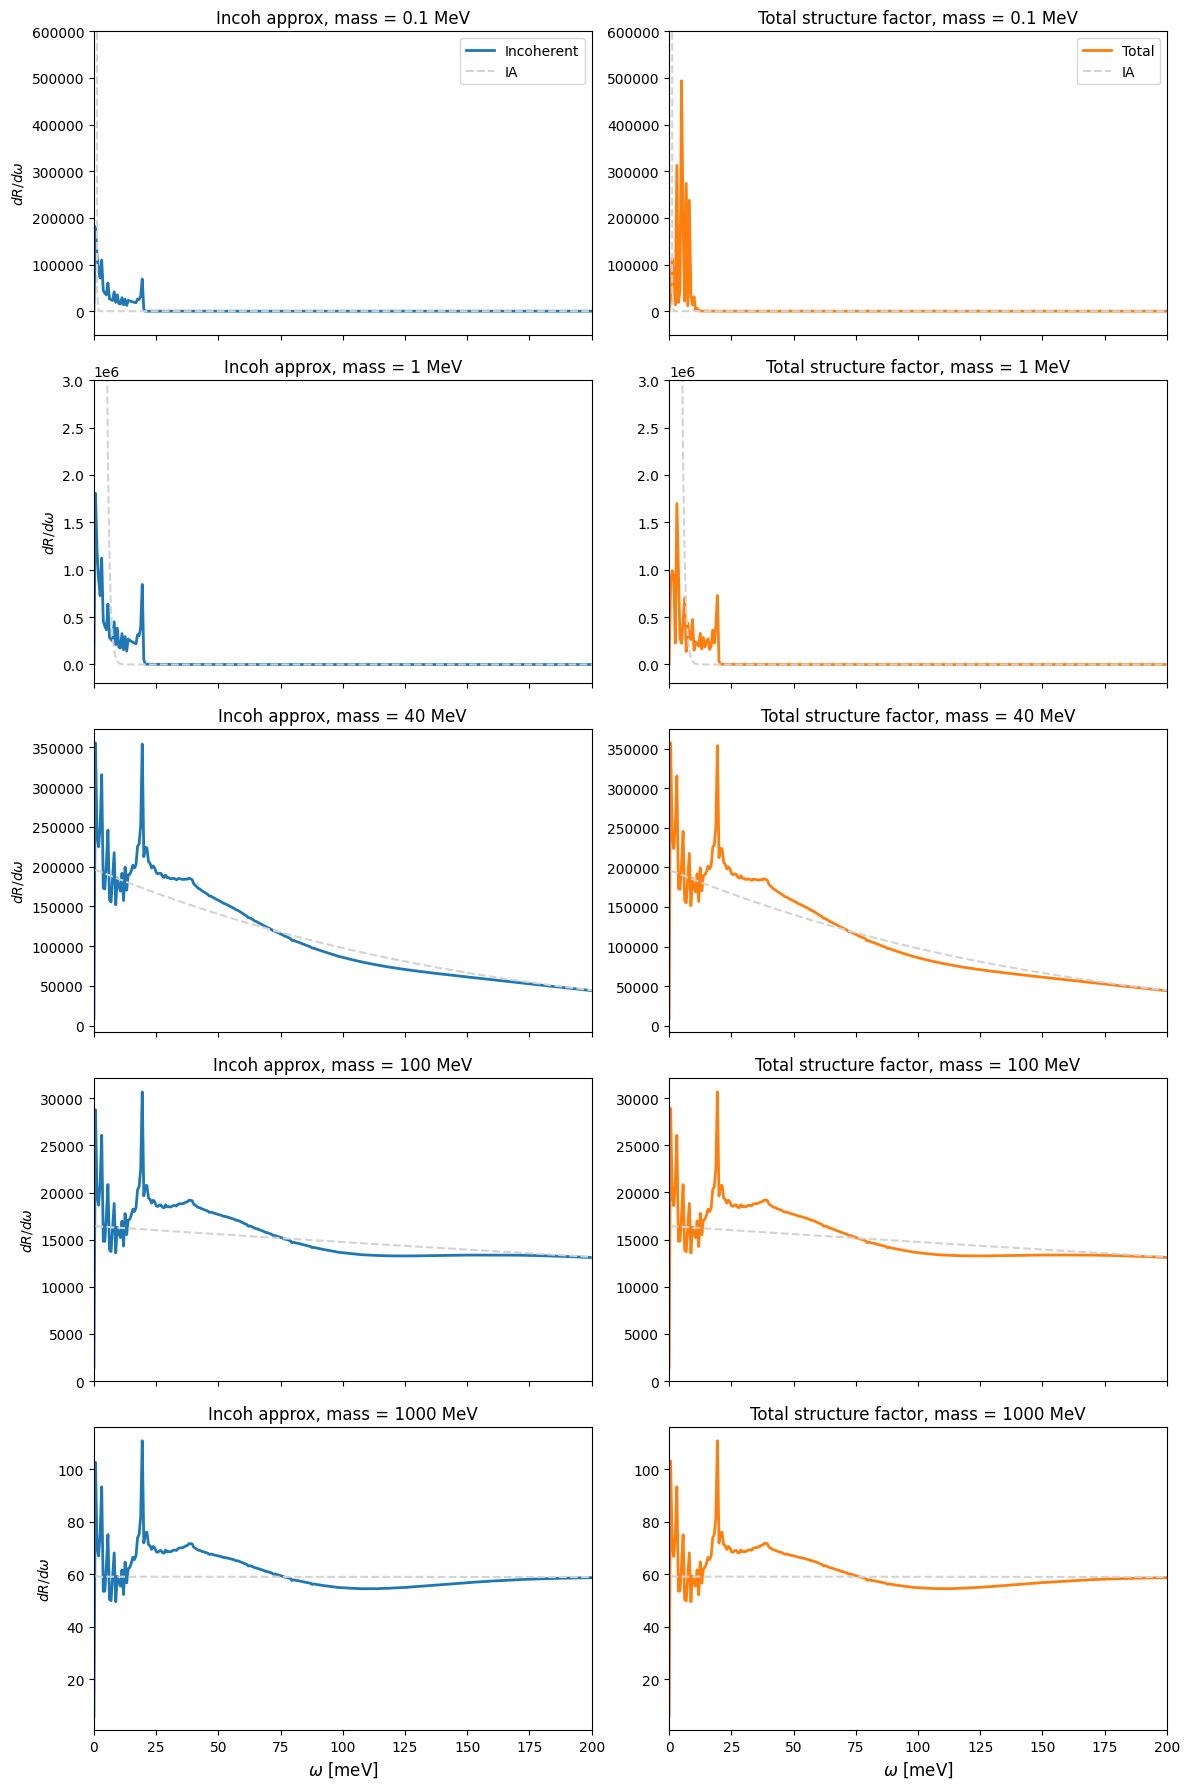

In [ ]:
def plot_rate_grid(dmmasslist, omega_list, rates_tot, rates_incoh):
    """
    Creates a 5x2 subplot grid.
    Rows correspond to different DM masses.
    Col 0 is the (incoherent) rate, Col 1 is the total rate.
    """
    # Create the 5x2 figure. sharex=True keeps the x-axis ticks only on the bottom row.
    fig, axes = plt.subplots(nrows=len(dmmasslist), ncols=2, figsize=(12, 18), sharex=True)
    
    for i, m_dm in enumerate(dmmasslist):
        # --- Column 0: Diagonal (Incoherent) ---
        ax_diag = axes[i, 0]
        ax_diag.plot(omega_list*1e6, rates_incoh[i], color='tab:blue', linewidth=2,label="Incoherent")
        # ax_diag.plot(omega_list*1e6, sp.signal.savgol_filter(rates_incoh[i], 20, 2), color='tab:green', linewidth=1.5)
        ax_diag.plot(omega_list*1e6, dRdomega_impulse_tot[i], color="lightgray", linestyle="--",label="IA")
        # ax_diag.set_yscale('log')
        ax_diag.set_title(f'Incoh approx, mass = {m_dm/1000:g} MeV', fontsize=12)
        if i == 0:
            ax_diag.set_ylim(-.05e6,.6e6)
            ax_diag.legend()
        if i == 1:
            ax_diag.set_ylim(-.2e6,3e6)
        ax_diag.set_ylabel('$dR/d\omega$', fontsize=10)
        ax_diag.set_xlim(0,200)        
        # --- Column 1: Total ---
        ax_tot = axes[i, 1]
        ax_tot.plot(omega_list*1e6, rates_tot[i], color='tab:orange', linewidth=2,  label="Total")
        # ax_tot.plot(omega_list*1e6, sp.signal.savgol_filter(rates_tot[i], 20, 2), color='tab:red', linewidth=2)
        # ax_tot.set_yscale('log')
        ax_tot.set_title(f'Total structure factor, mass = {m_dm/1000:g} MeV', fontsize=12,)
        # ax_tot.grid(True, which="both", linestyle="--", alpha=0.6)
        ax_tot.plot(omega_list*1e6, dRdomega_impulse_tot[i], color="lightgray", linestyle="--",label="IA")
        if i == 0:
            ax_tot.set_ylim(-.05e6,.6e6)
            ax_tot.legend()
        if i == 1:
            ax_tot.set_ylim(-.2e6,3e6)
        # Add x-axis labels only to the bottom row to keep the plot clean
        if i == len(dmmasslist) - 1:
            ax_diag.set_xlabel('$\omega$ [meV]', fontsize=12)
            ax_tot.set_xlabel('$\omega$ [meV]', fontsize=12)

    # Automatically adjust subplot parameters to give specified padding
    plt.tight_layout()
    plt.show()

# --- Implementation ---
# Pass your previously calculated arrays into the new plotting function
plot_rate_grid(dmmasslist_4plot, omega_list_nSite, dRdomega_result_4plot, dRdomega_result_incoh_4plot)

## Sanity check: calculate scattering rate

In [ ]:
dm_length = 200
dmmasslist = 10**np.linspace(1, 6, dm_length) # keV
omega_threshold = 1e-6 # keV
v_max = 0.00247 # in c
cross_section = 1e-40 # Ensure you define your target cross section

# Results arrays
rate_result = np.zeros(dm_length)
rate_result_incoh = np.zeros(dm_length)

for ind_m, dmmass in enumerate(dmmasslist):    
    if ind_m % 10 == 0: 
        print(f'Processing mass index {ind_m} (Mass: {dmmass:.2e} keV)...')
        
    # 1. Kinematic max omega for this specific DM mass
    # Derived from setting the square root in get_q_lim to 0
    omega_max_kinematic = 0.5 * dmmass * (v_max**2)
    
    # If the DM is too light to even reach the threshold, rate is 0
    if omega_max_kinematic <= omega_threshold:
        continue
        
    # 2. Build the omegalist for integration
    # Find which nSite omegas are valid (between threshold and kinematic max)
    valid_nsite_idx = np.where((omega_list_nSite >= omega_threshold) & (omega_list_nSite <= omega_max_kinematic))[0]
    omega_nSite_valid = omega_list_nSite[valid_nsite_idx]
    
    # If kinematic max exceeds our nSite data, we must extend the omega grid
    if omega_max_kinematic > omega_list_nSite[-1]:
        omega_length_ext = 1000
        # generate extended array, [1:] drops the overlapping point
        omega_extended = np.linspace(omega_list_nSite[-1], omega_max_kinematic, omega_length_ext + 1)[1:]
        omegalist = np.concatenate((omega_nSite_valid, omega_extended))
    else:
        omegalist = omega_nSite_valid
        
    # Safety check: Simpson's rule needs at least 2 points
    if len(omegalist) < 2:
        continue

    # Arrays to store dR/domega for this specific DM mass
    dRdomega_result = np.zeros(len(omegalist))
    dRdomega_result_incoh = np.zeros(len(omegalist))
    
    # 3. Loop through each omega to calculate dR/domega
    for ind_w, omega in enumerate(omegalist):
        # Kinematic q limits for this specific omega
        q_min_lim, q_max_lim = get_q_lim(dmmass, omega)
        
        # Determine if we are using nSite data or purely Impulse Approximation
        if ind_w < len(valid_nsite_idx):
            # A. Omega is covered by nSite data
            orig_w_idx = valid_nsite_idx[ind_w]
            current_q_max = q_list_nSite[-1]
            
            if q_max_lim > current_q_max:
                # Extend q list via impulse approx
                q_length_ext = 1000
                q_extra = np.linspace(current_q_max, q_max_lim, q_length_ext + 1)[1:]
                q_combined = np.concatenate((q_list_nSite, q_extra))
                
                s_extra = get_impulse_approx(q_extra, omega)
                s_tot_combined = np.concatenate((s_factor_nSite[:, orig_w_idx], s_extra))
                s_incoh_combined = np.concatenate((s_factor_nSite_incoh[:, orig_w_idx], s_extra))
            else:
                # nSite q range is entirely sufficient
                q_combined = q_list_nSite
                s_tot_combined = s_factor_nSite[:, orig_w_idx]
                s_incoh_combined = s_factor_nSite_incoh[:, orig_w_idx]
        else:
            # B. Omega is in the extended region (No nSite data available)
            # Use Impulse Approximation for the entire q range
            if q_min_lim >= q_max_lim: # Safety check
                continue
            
            q_length_ext = 1000
            q_combined = np.linspace(q_min_lim, q_max_lim, q_length_ext)
            
            s_tot_combined = get_impulse_approx(q_combined, omega)
            s_incoh_combined = s_tot_combined # Total & incoh are identical in pure IA
            
        # 4. Calculate dR/domega using your existing class method
        rateCal = RateCalculations(dmmass, omega, q_combined, s_tot_combined, cross_section)
        dRdomega_result[ind_w] = rateCal.get_diff_rate_dRdomega()
        
        rateCal_incoh = RateCalculations(dmmass, omega, q_combined, s_incoh_combined, cross_section)
        dRdomega_result_incoh[ind_w] = rateCal_incoh.get_diff_rate_dRdomega()
        
    # 5. Integrate dR/domega over omega to get the total rate (per kg-year)
    rate_result[ind_m] = sp.integrate.simpson(dRdomega_result, omegalist)
    rate_result_incoh[ind_m] = sp.integrate.simpson(dRdomega_result_incoh, omegalist)

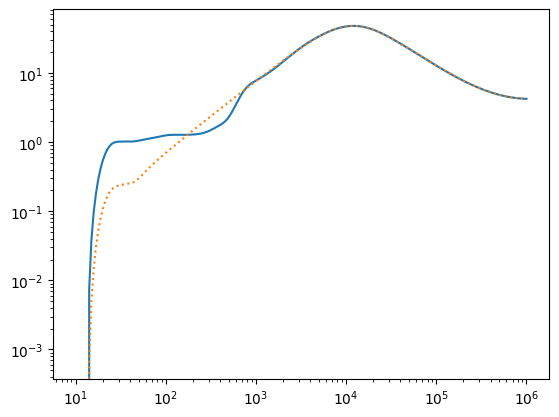

In [18]:
plt.plot(dmmasslist, rate_result,label='N site coherent, $\omega_{th} =$1meV')
plt.plot(dmmasslist, rate_result_incoh,label='N site incoh approx, $\omega_{th} =$1meV', linestyle=':')
plt.yscale('log')
plt.xscale('log')